In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='darkgrid', context='notebook')

In [ ]:
from preprocessing import prepare_train

train = prepare_train('data/train.csv')


In [ ]:
female_count = (train['Sex'] == 0).sum()
male_count = (train['Sex'] == 1).sum()

female_survivors = ((train['Sex'] == 0) & (train['Survived'] == 1)).sum()
female_dead = ((train['Sex'] == 0) & (train['Survived'] == 0)).sum()
male_survivors = ((train['Sex'] == 1) & (train['Survived'] == 1)).sum()
male_dead = ((train['Sex'] == 1) & (train['Survived'] == 0)).sum()


([<matplotlib.patches.Wedge at 0x133d107d0>,
 [Text(0.4964175759917634, 0.9928089394472948, 'female'),
  Text(-0.49194502499358117, -0.983864875063677, 'male')],
 [Text(0.2728060552747528, 0.5455977054620268, '35%'),
  Text(-0.2683336499964988, -0.5366535682165511, '65%')])

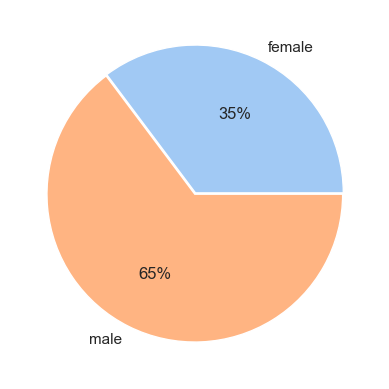

In [11]:
explode = [0.01, 0]
names = ['female', 'male']
counts = [female_count, male_count]
colors = sns.color_palette('pastel')
plt.pie(counts, labels=names, explode=explode, autopct='%.0f%%', colors=colors)

Text(0, 0.5, 'Quantity')

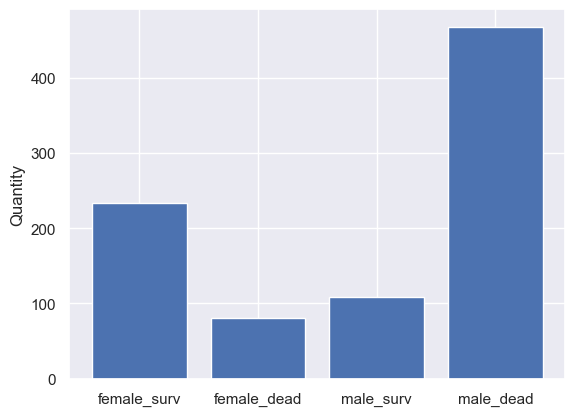

In [12]:
names = ['female_surv', 'female_dead', 'male_surv', 'male_dead']
counts = [female_survivors, female_dead, male_survivors, male_dead]
plt.bar(names, counts)
plt.ylabel('Quantity')

Text(0, 0.5, 'Survivor rates')

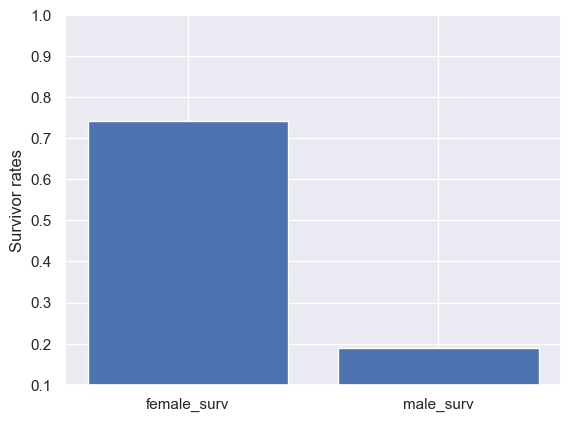

In [13]:
male_survivors_rate = male_survivors / male_count
female_survivors_rate = female_survivors / female_count

names = ['female_surv', 'male_surv']
percentage_counts = [female_survivors_rate, male_survivors_rate]
plt.bar(names, percentage_counts)
plt.ylim(0.1, 1)
plt.ylabel('Survivor rates')


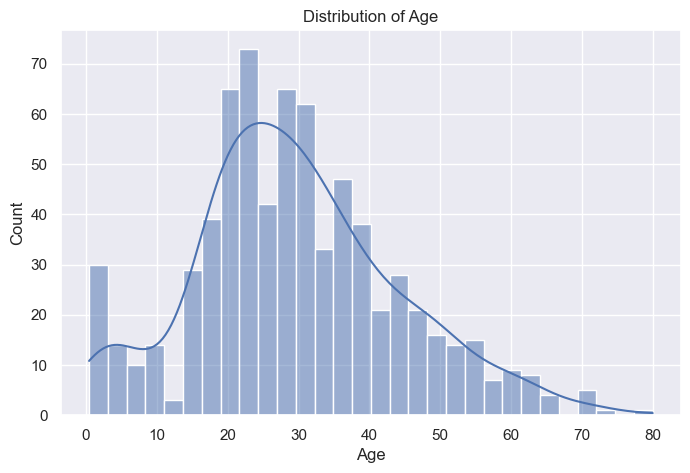

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(train['Age'], bins=30, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

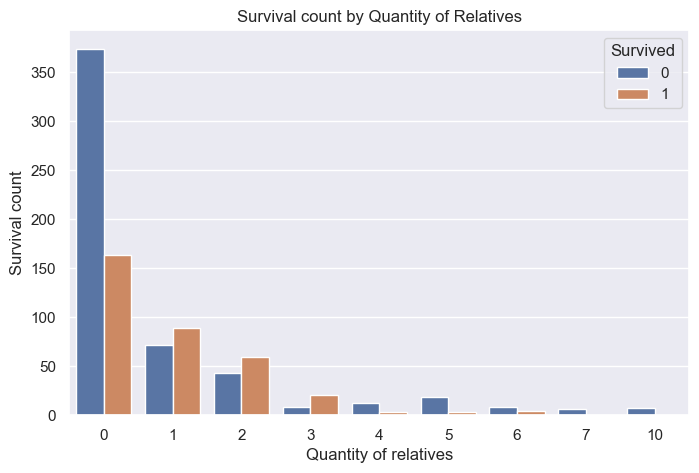

In [15]:
plt.figure(figsize=(8, 5))
sns.countplot(x = 'Relatives', data = train,  hue='Survived')
plt.title('Survival count by Quantity of Relatives')
plt.xlabel('Quantity of relatives')
plt.ylabel('Survival count')
plt.show()

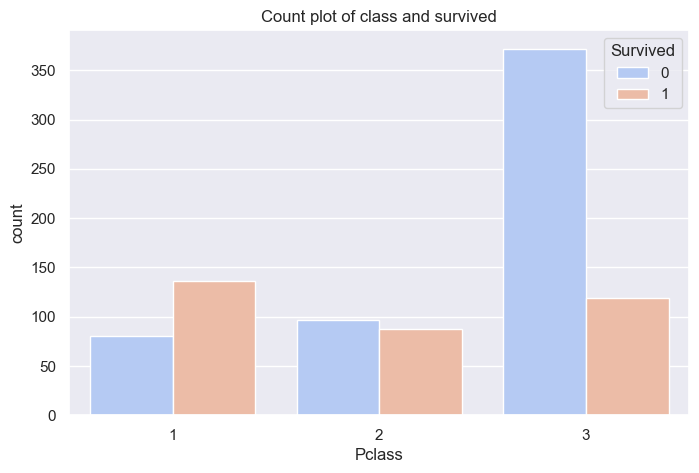

In [16]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Pclass', data=train, hue='Survived', palette='coolwarm')
plt.title('Count plot of class and survived')
plt.show()

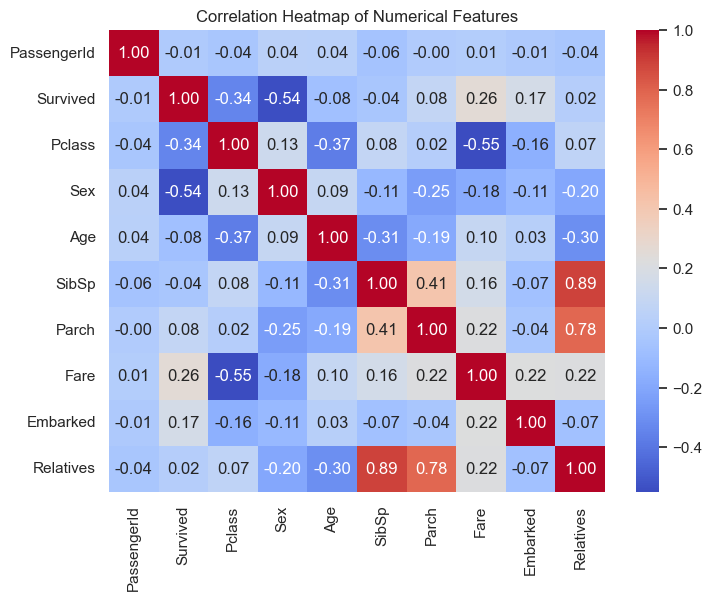

In [17]:
plt.figure(figsize=(8, 6))
numerical_columns = train.select_dtypes(include=['int64', 'float64']).columns  # Select only numerical columns
sns.heatmap(train[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

<Figure size 1000x1000 with 0 Axes>

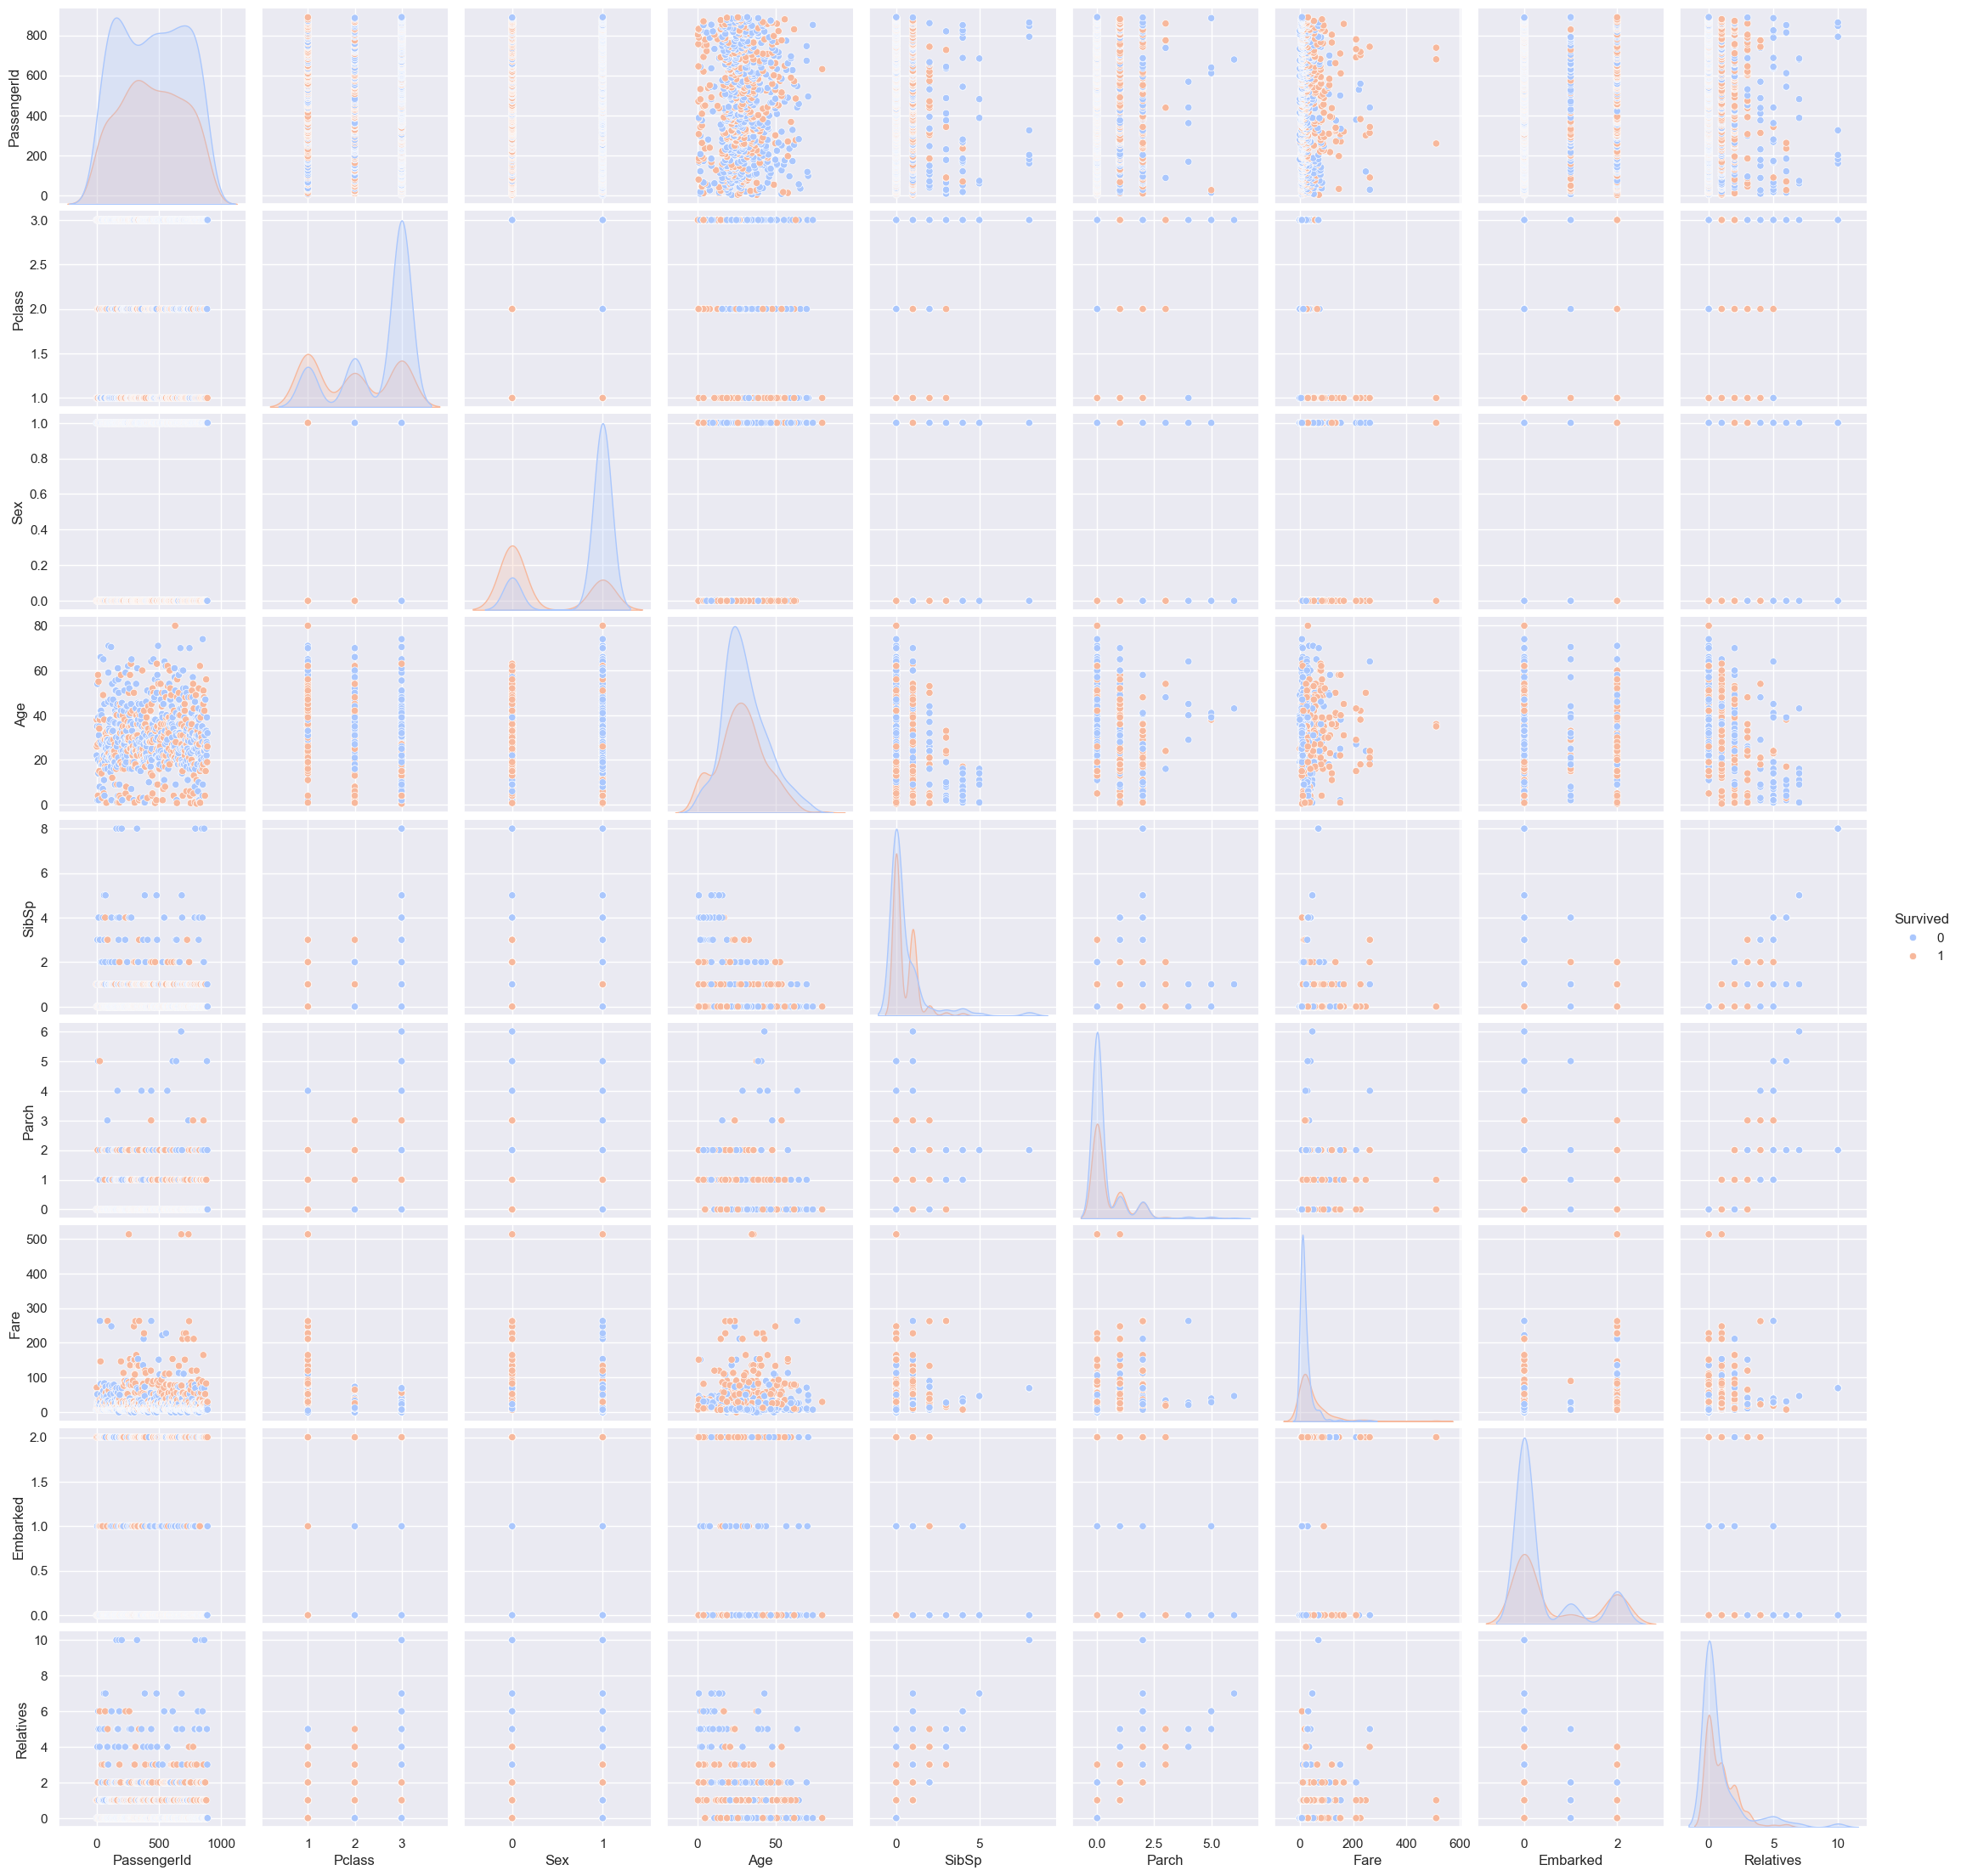

In [18]:
plt.figure(figsize=(10, 10))
sns.pairplot(train, hue='Survived', diag_kind='kde', palette='coolwarm')
plt.show()